# Coffee Quality EDA: What Makes Great Coffee & Which Flavors Go Together?

**Goal:** Investigate the specialty coffee dataset to answer two questions:
1. Which flavors co-occur (go well together)?
2. What flavor/origin/roast characteristics predict high ratings?

**Data source:** Coffee Review dataset (Kaggle) — ~2,000 professional tasting reviews with ratings, origins, roast levels, and detailed tasting notes.

---
**Analysis outline:**
- Section 1: Data Loading & Cleaning
- Section 2: Descriptive Statistics & Distributions
- Section 3: Origin & Roast Analysis
- Section 4: Flavor Extraction
- Section 5: Flavor Co-occurrence (PMI Analysis)
- Section 6: Flavor Network & Communities
- Section 7: What Predicts High Ratings? (Feature Importance)
- Section 8: Cluster Analysis — Flavor Profiles
- Section 9: Key Findings

## Section 1: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
from collections import Counter
from itertools import combinations

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('husl')
SEED = 42
print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('data/coffee_analysis.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (2095, 12)
Columns: ['name', 'roaster', 'roast', 'loc_country', 'origin_1', 'origin_2', '100g_USD', 'rating', 'review_date', 'desc_1', 'desc_2', 'desc_3']


,name,roaster,roast,loc_country,origin_1,origin_2,100g_USD,rating,review_date,desc_1,desc_2,desc_3
0,“Sweety” Espresso Blend,A.R.C.,Medium-Light,Hong Kong,Panama,Ethiopia,14.32,95,November 2017,"Evaluated as espresso. Sweet-toned, deeply ric...",An espresso blend comprised of coffees from Pa...,A radiant espresso blend that shines equally i...
1,Flora Blend Espresso,A.R.C.,Medium-Light,Hong Kong,Africa,Asia Pacific,9.05,94,November 2017,"Evaluated as espresso. Sweetly tart, floral-to...",An espresso blend comprised of coffees from Af...,"A floral-driven straight shot, amplified with ..."
2,Ethiopia Shakiso Mormora,Revel Coffee,Medium-Light,United States,Guji Zone,Southern Ethiopia,4.70,92,November 2017,"Crisply sweet, cocoa-toned. Lemon blossom, roa...",This coffee tied for the third-highest rating ...,"A gently spice-toned, floral- driven wet-proce..."


In [3]:
# ── Data types and non-null counts ──────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095 entries, 0 to 2094
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         2095 non-null   object 
 1   roaster      2095 non-null   object 
 2   roast        2080 non-null   object 
 3   loc_country  2095 non-null   object 
 4   origin_1     2095 non-null   object 
 5   origin_2     2095 non-null   object 
 6   100g_USD     2095 non-null   float64
 7   rating       2095 non-null   int64  
 8   review_date  2095 non-null   object 
 9   desc_1       2095 non-null   object 
 10  desc_2       2095 non-null   object 
 11  desc_3       2093 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 196.5+ KB


In [4]:
# ── Missing values ───────────────────────────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'count': missing[missing > 0], 'pct': missing_pct[missing > 0]})

,count,pct
roast,15,0.7
desc_3,2,0.1


In [5]:
# ── Cleaning ─────────────────────────────────────────────────────────────────
df['review_date'] = pd.to_datetime(df['review_date'], format='%B %Y', errors='coerce')
df['year'] = df['review_date'].dt.year
df['100g_USD'] = pd.to_numeric(df['100g_USD'], errors='coerce')

# Tasting notes live in desc_1; desc_3 is the short summary — both are flavor-relevant
df['tasting_text'] = (
    df['desc_1'].fillna('') + ' ' + df['desc_3'].fillna('')
).str.lower().str.strip()

# Standardize roast levels
roast_order = ['Light', 'Medium-Light', 'Medium', 'Medium-Dark', 'Dark']
df['roast'] = df['roast'].str.strip()
df = df[df['roast'].isin(roast_order)].copy()  # drop "N/A" entries
df['roast'] = pd.Categorical(df['roast'], categories=roast_order, ordered=True)

# Binary target: high-rated = top quartile
rating_q75 = df['rating'].quantile(0.75)
df['high_rated'] = (df['rating'] >= rating_q75).astype(int)

print(f'Clean dataset: {df.shape[0]} rows')
print(f'Rating Q75 threshold (high-rated): {rating_q75}')
df[['rating', '100g_USD']].describe().round(2)

Clean dataset: 2080 rows
Rating Q75 threshold (high-rated): 94.0


,rating,100g_USD
count,2080.00,2080.00
mean,93.11,9.09
std,1.56,10.34
min,84.00,0.17
25%,92.00,4.93
50%,93.00,5.86
75%,94.00,8.77
max,98.00,132.28


## Section 2: Descriptive Statistics & Distributions

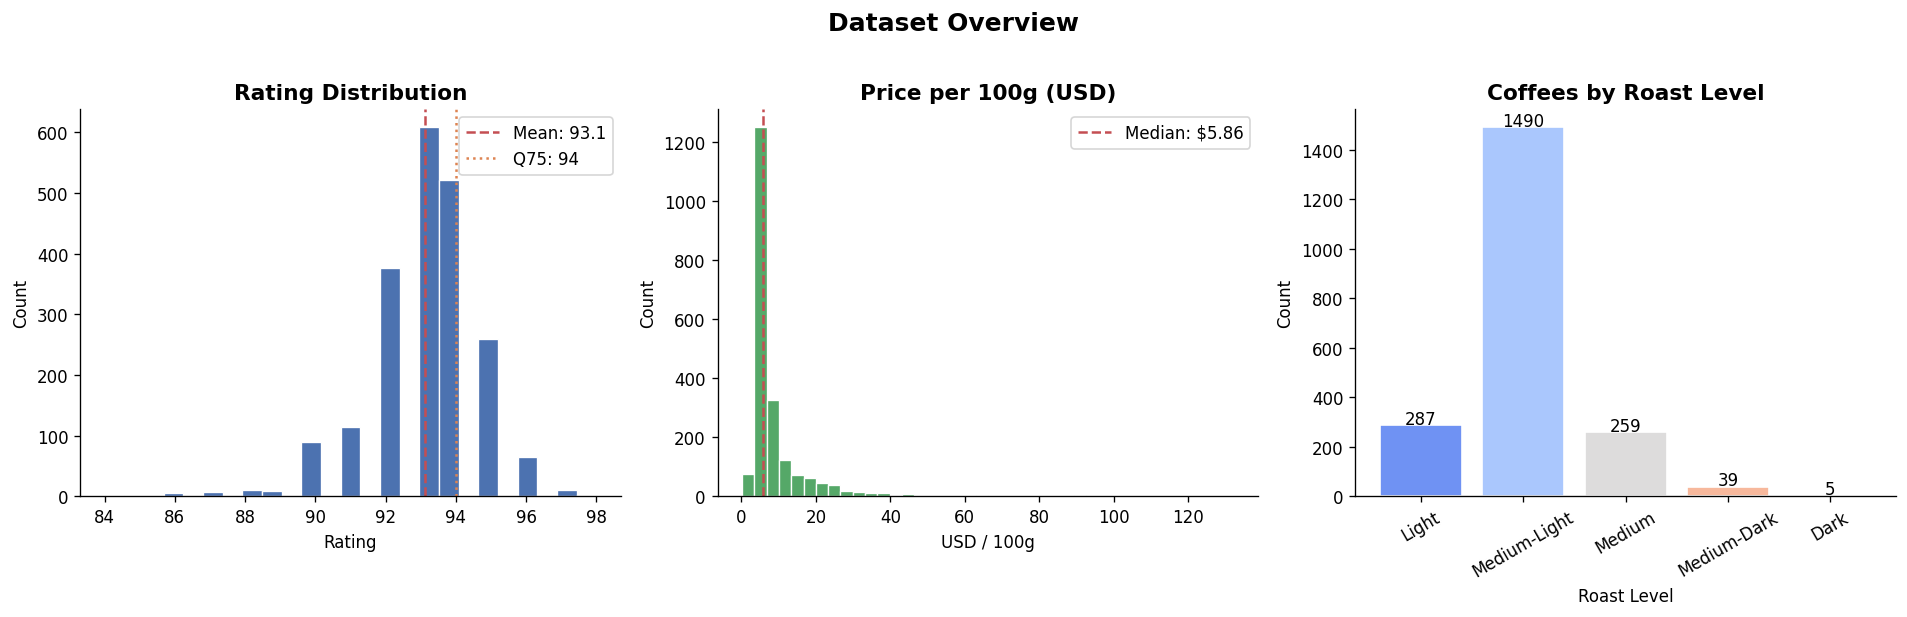

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Rating distribution
axes[0].hist(df['rating'], bins=25, color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['rating'].mean(), color='#C44E52', linestyle='--', linewidth=1.5,
                label=f"Mean: {df['rating'].mean():.1f}")
axes[0].axvline(rating_q75, color='#DD8452', linestyle=':', linewidth=1.5,
                label=f"Q75: {rating_q75:.0f}")
axes[0].set_title('Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
axes[0].legend()

# Price distribution (log scale)
price_clean = df['100g_USD'].dropna()
axes[1].hist(price_clean, bins=40, color='#55A868', edgecolor='white', linewidth=0.8)
axes[1].axvline(price_clean.median(), color='#C44E52', linestyle='--', linewidth=1.5,
                label=f"Median: ${price_clean.median():.2f}")
axes[1].set_title('Price per 100g (USD)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('USD / 100g'); axes[1].set_ylabel('Count')
axes[1].legend()

# Roast level counts
roast_counts = df['roast'].value_counts().reindex(roast_order)
colors = sns.color_palette('coolwarm', len(roast_order))
bars = axes[2].bar(roast_counts.index, roast_counts.values, color=colors, edgecolor='white')
axes[2].set_title('Coffees by Roast Level', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Roast Level'); axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, roast_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=10)

plt.suptitle('Dataset Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

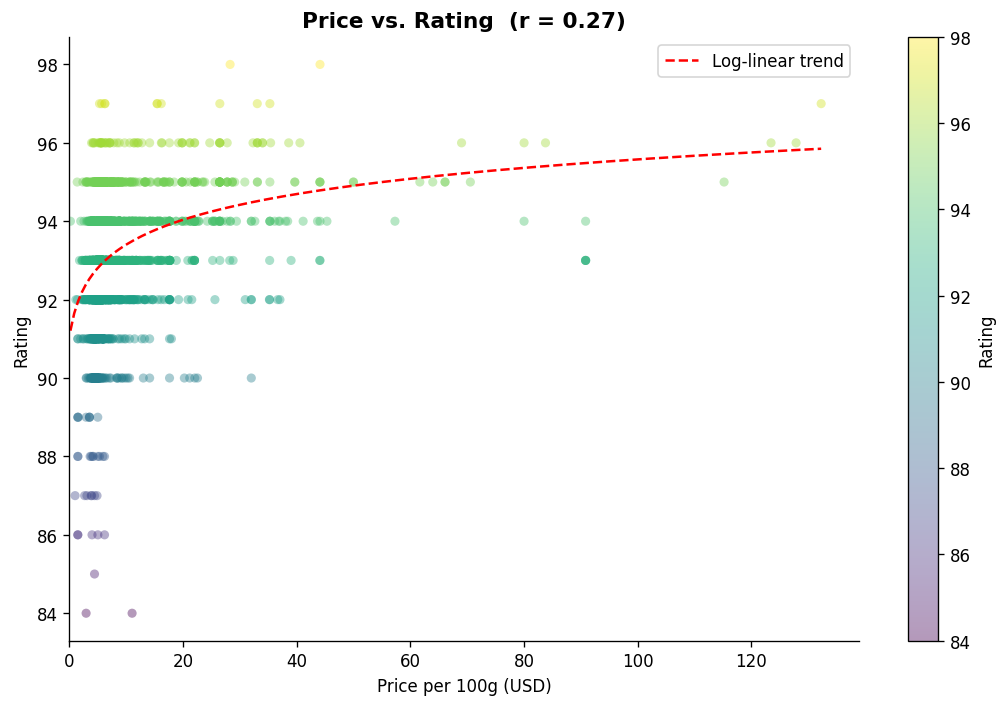

Pearson correlation (price, rating): 0.272


In [7]:
# ── Price vs Rating scatter ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    df['100g_USD'], df['rating'],
    alpha=0.4, s=30, c=df['rating'], cmap='viridis', edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Rating')

# Trend line
valid = df[['100g_USD', 'rating']].dropna()
z = np.polyfit(np.log1p(valid['100g_USD']), valid['rating'], 1)
x_range = np.linspace(valid['100g_USD'].min(), valid['100g_USD'].max(), 200)
ax.plot(x_range, np.polyval(z, np.log1p(x_range)), 'r--', linewidth=1.5,
        label='Log-linear trend')

corr = valid[['100g_USD', 'rating']].corr().iloc[0, 1]
ax.set_title(f'Price vs. Rating  (r = {corr:.2f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Price per 100g (USD)')
ax.set_ylabel('Rating')
ax.set_xlim(left=0)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Pearson correlation (price, rating): {corr:.3f}')

## Section 3: Origin & Roast Analysis

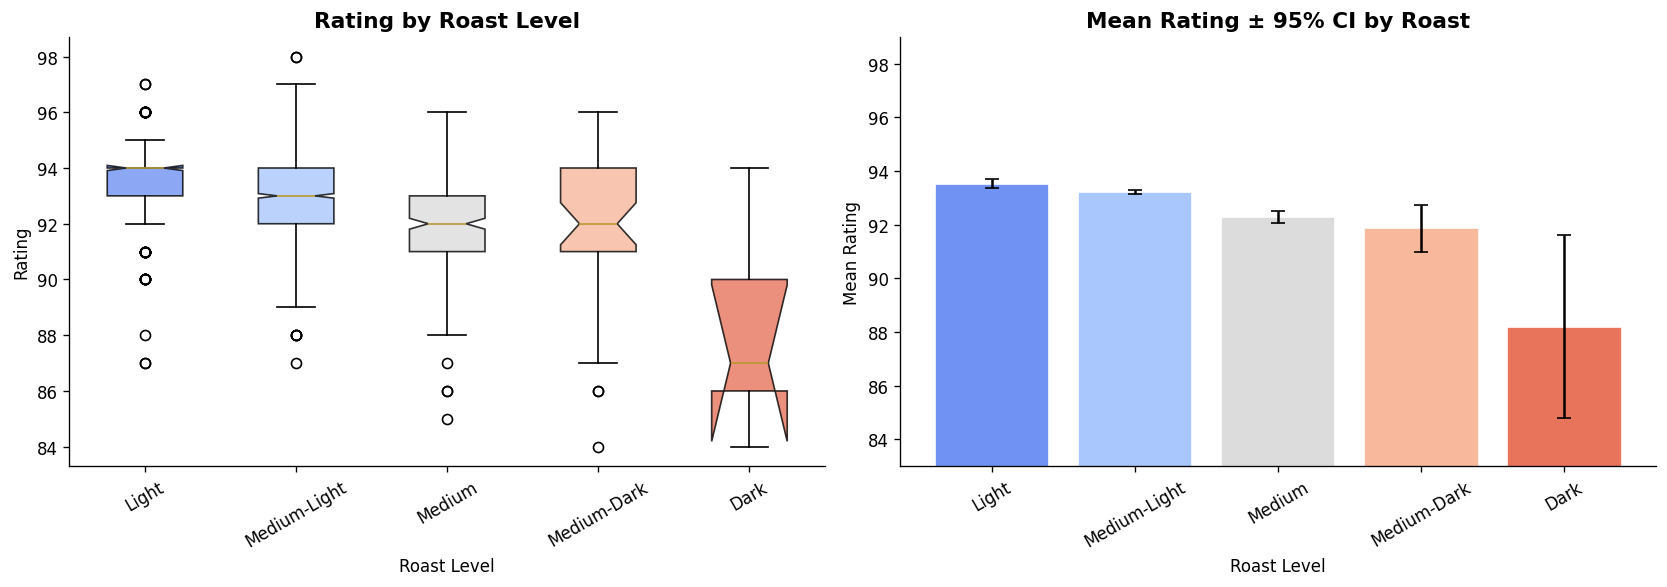

In [8]:
# ── Rating by roast level ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: rating by roast
roast_groups = [df[df['roast'] == r]['rating'].values for r in roast_order]
bp = axes[0].boxplot(roast_groups, labels=roast_order, patch_artist=True, notch=True)
colors = sns.color_palette('coolwarm', len(roast_order))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title('Rating by Roast Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Roast Level'); axes[0].set_ylabel('Rating')
axes[0].tick_params(axis='x', rotation=30)

# Mean rating by roast
roast_rating = df.groupby('roast', observed=True)['rating'].agg(['mean', 'sem']).reindex(roast_order)
axes[1].bar(roast_rating.index, roast_rating['mean'],
            yerr=roast_rating['sem'] * 1.96, capsize=4,
            color=colors, edgecolor='white')
axes[1].set_ylim(df['rating'].min() - 1, df['rating'].max() + 1)
axes[1].set_title('Mean Rating ± 95% CI by Roast', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Roast Level'); axes[1].set_ylabel('Mean Rating')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

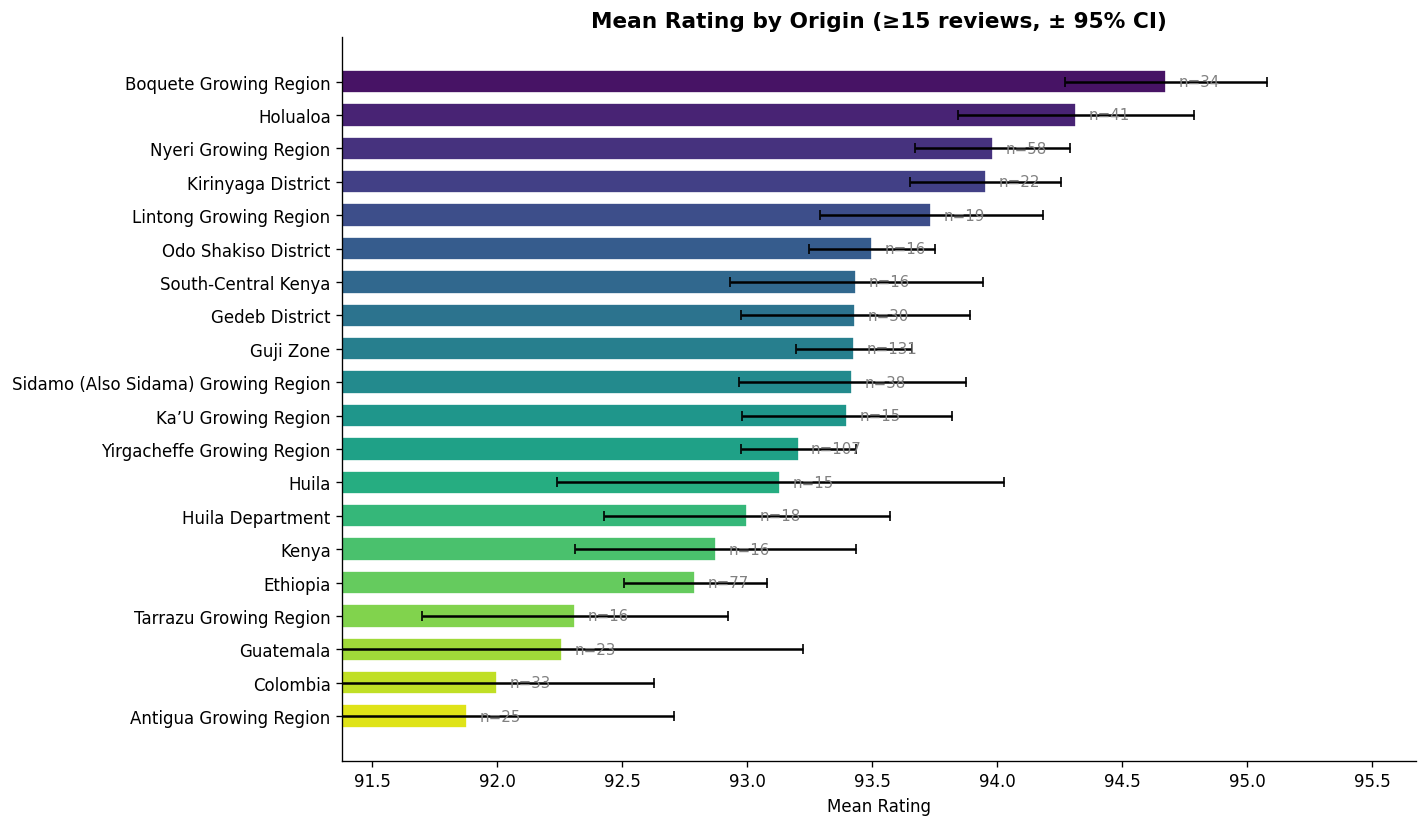

In [9]:
# ── Top origins by count and mean rating ─────────────────────────────────────
origin_stats = (
    df.groupby('origin_1')
    .agg(count=('rating', 'count'), mean_rating=('rating', 'mean'), sem=('rating', 'sem'))
    .query('count >= 15')   # only origins with enough samples
    .sort_values('mean_rating', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
colors_origin = sns.color_palette('viridis', len(origin_stats))
bars = ax.barh(origin_stats.index, origin_stats['mean_rating'],
               xerr=origin_stats['sem'] * 1.96, capsize=3,
               color=colors_origin, edgecolor='white', height=0.7)

# Annotate count
for bar, (_, row) in zip(bars, origin_stats.iterrows()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'n={int(row["count"])}', va='center', fontsize=9, color='gray')

ax.set_xlim(origin_stats['mean_rating'].min() - 0.5, origin_stats['mean_rating'].max() + 1)
ax.set_title('Mean Rating by Origin (≥15 reviews, ± 95% CI)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Rating')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

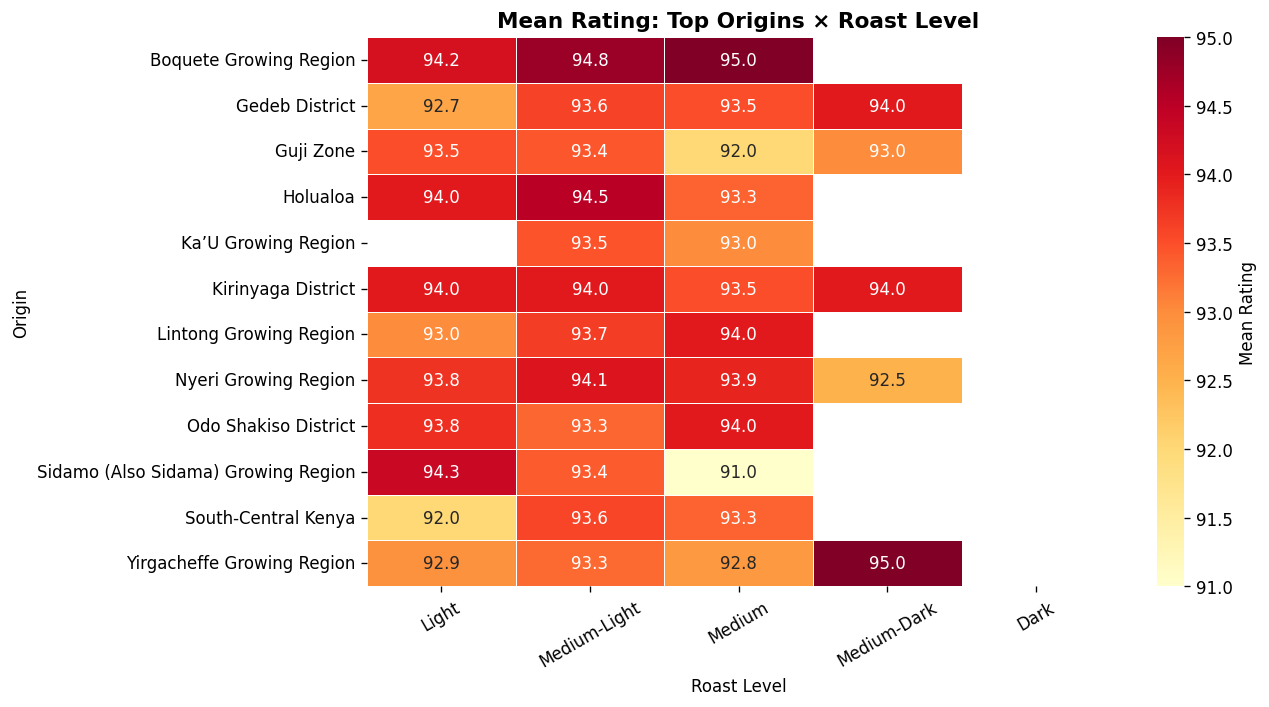

In [10]:
# ── Heatmap: origin × roast — mean rating ────────────────────────────────────
top_origins = origin_stats.head(12).index.tolist()
pivot = (
    df[df['origin_1'].isin(top_origins)]
    .groupby(['origin_1', 'roast'], observed=True)['rating']
    .mean()
    .unstack('roast')
    .reindex(columns=roast_order)
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Mean Rating'}, ax=ax
)
ax.set_title('Mean Rating: Top Origins × Roast Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Roast Level'); ax.set_ylabel('Origin')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Section 4: Flavor Extraction

We use phrase-level matching to capture multi-word descriptors (e.g., *dark chocolate*, *lemon blossom*) that a single-token vocabulary would miss. Each term is grouped into a broader category for summary analysis.

In [11]:
# ── Expanded flavor vocabulary with categories ────────────────────────────────
FLAVOR_TERMS = {
    # Chocolate / Roasty
    'dark chocolate':    'chocolate',
    "baker's chocolate": 'chocolate',
    'milk chocolate':    'chocolate',
    'chocolate truffle': 'chocolate',
    'roasted cacao':     'chocolate',
    'cocoa powder':      'chocolate',
    'cocoa nib':         'chocolate',
    'chocolate':         'chocolate',
    'cocoa':             'chocolate',
    'nougat':            'chocolate',
    # Caramel / Sweet
    'caramel':           'caramel_sweet',
    'brown sugar':       'caramel_sweet',
    'maple syrup':       'caramel_sweet',
    'molasses':          'caramel_sweet',
    'toffee':            'caramel_sweet',
    'honey':             'caramel_sweet',
    'vanilla':           'caramel_sweet',
    # Berry / Fruit
    'blueberry':         'berry',
    'raspberry':         'berry',
    'strawberry':        'berry',
    'blackberry':        'berry',
    'red currant':       'berry',
    'black cherry':      'berry',
    'cherry':            'berry',
    'mulberry':          'berry',
    'pie cherry':        'berry',
    # Stone Fruit / Tropical
    'peach':             'stone_tropical',
    'apricot':           'stone_tropical',
    'mango':             'stone_tropical',
    'guava':             'stone_tropical',
    'papaya':            'stone_tropical',
    'plum':              'stone_tropical',
    'fig':               'stone_tropical',
    'date':              'stone_tropical',
    # Citrus
    'lemon blossom':     'citrus',
    'lemon zest':        'citrus',
    'orange zest':       'citrus',
    'tangerine zest':    'citrus',
    'grapefruit zest':   'citrus',
    'grapefruit':        'citrus',
    'bergamot':          'citrus',
    'lemon':             'citrus',
    'orange':            'citrus',
    'lime':              'citrus',
    # Floral
    'jasmine':           'floral',
    'rose':              'floral',
    'lavender':          'floral',
    'gardenia':          'floral',
    'magnolia':          'floral',
    'honeysuckle':       'floral',
    'lilac':             'floral',
    'floral':            'floral',
    'hibiscus':          'floral',
    'wisteria':          'floral',
    'freesia':           'floral',
    'violet':            'floral',
    # Nut
    'almond':            'nutty',
    'hazelnut':          'nutty',
    'pistachio':         'nutty',
    'walnut':            'nutty',
    'peanut':            'nutty',
    'pecan':             'nutty',
    'nutty':             'nutty',
    # Spice
    'cinnamon':          'spice',
    'clove':             'spice',
    'cardamom':          'spice',
    'black peppercorn':  'spice',
    'white peppercorn':  'spice',
    'pink peppercorn':   'spice',
    'ginger':            'spice',
    'allspice':          'spice',
    'nutmeg':            'spice',
    'spice':             'spice',
    # Earthy / Woody
    'cedar':             'earthy_woody',
    'sandalwood':        'earthy_woody',
    'tobacco':           'earthy_woody',
    'pipe tobacco':      'earthy_woody',
    'earth':             'earthy_woody',
    'oak':               'earthy_woody',
    'frankincense':      'earthy_woody',
    'myrrh':             'earthy_woody',
}

# Sort longest phrases first so multi-word matches take priority
sorted_terms = sorted(FLAVOR_TERMS.keys(), key=len, reverse=True)

def extract_flavors(text):
    """Return list of matched flavor terms from a review string."""
    found = set()
    for term in sorted_terms:
        if re.search(r'\b' + re.escape(term) + r'\b', text):
            found.add(term)
    return list(found)

df['flavors'] = df['tasting_text'].apply(extract_flavors)
df['n_flavors'] = df['flavors'].apply(len)

print(f'Avg flavor terms per review: {df["n_flavors"].mean():.1f}')
print(f'Reviews with ≥1 flavor match: {(df["n_flavors"] > 0).sum()} / {len(df)}')

Avg flavor terms per review: 5.2
Reviews with ≥1 flavor match: 2079 / 2080


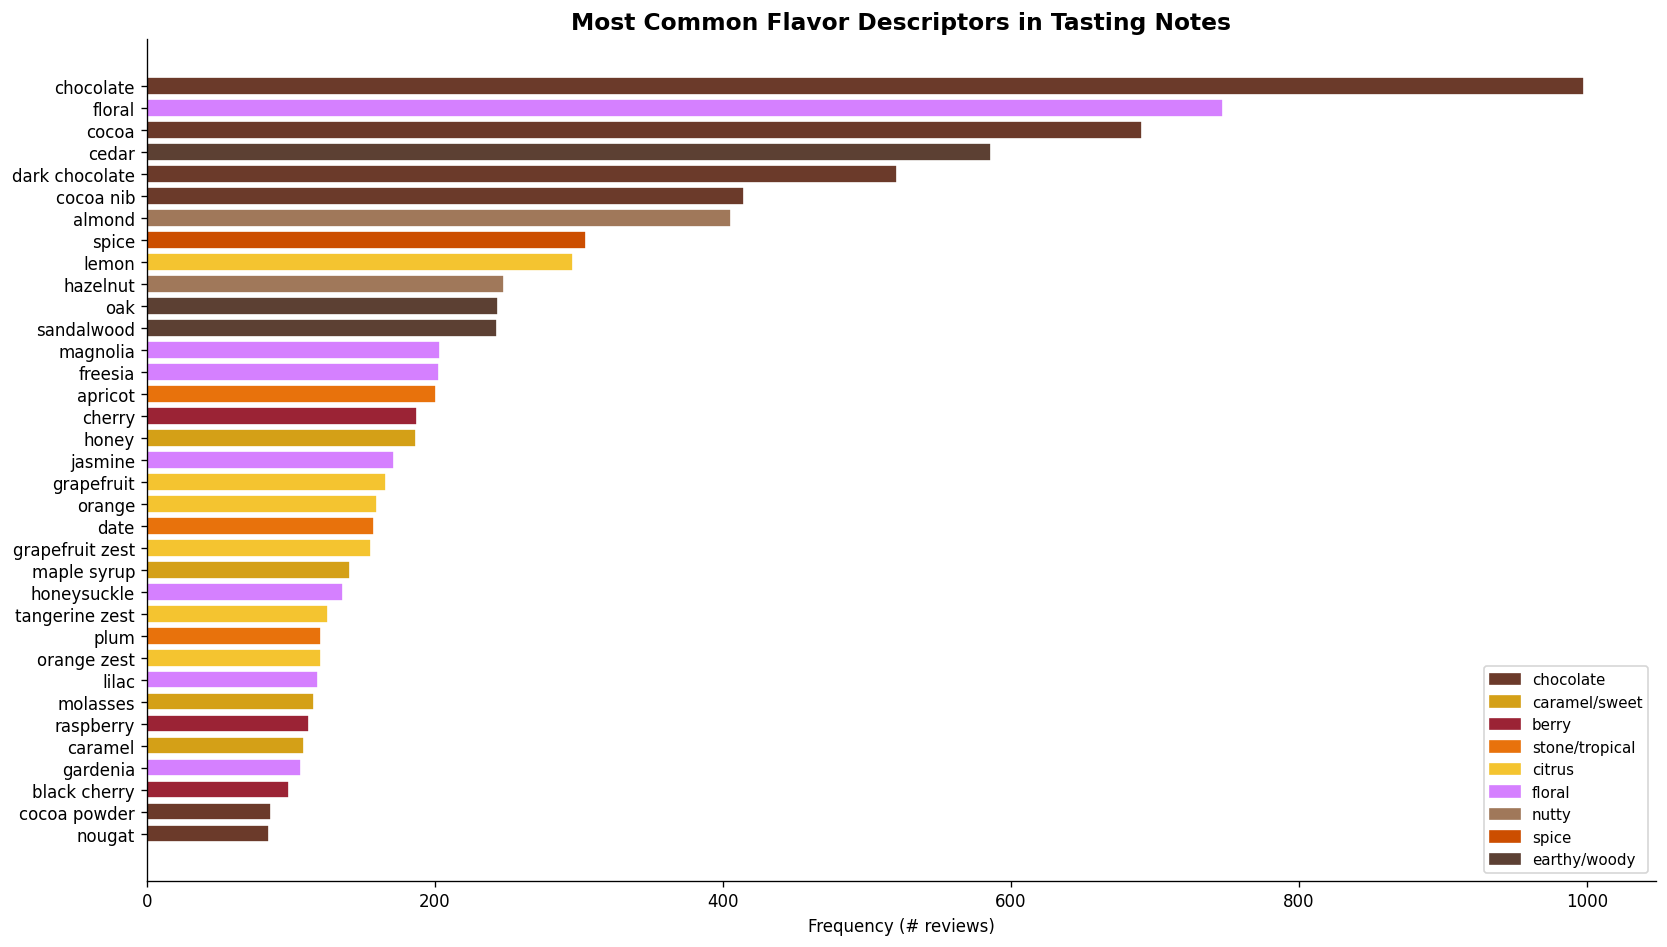

In [12]:
# ── Flavor term frequency ─────────────────────────────────────────────────────
all_flavor_counts = Counter(f for flavors in df['flavors'] for f in flavors)
freq_df = (
    pd.Series(all_flavor_counts)
    .sort_values(ascending=False)
    .head(35)
    .reset_index()
)
freq_df.columns = ['flavor', 'count']
freq_df['category'] = freq_df['flavor'].map(FLAVOR_TERMS)

cat_palette = {
    'chocolate':      '#6B3A2A',
    'caramel_sweet':  '#D4A017',
    'berry':          '#9B2335',
    'stone_tropical': '#E8720C',
    'citrus':         '#F4C430',
    'floral':         '#D580FF',
    'nutty':          '#A0785A',
    'spice':          '#CC4E00',
    'earthy_woody':   '#5C4033',
}

fig, ax = plt.subplots(figsize=(14, 8))
bar_colors = [cat_palette.get(c, '#888') for c in freq_df['category']]
bars = ax.barh(freq_df['flavor'], freq_df['count'], color=bar_colors, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Most Common Flavor Descriptors in Tasting Notes', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency (# reviews)')

# Legend for categories
legend_patches = [mpatches.Patch(color=v, label=k.replace('_', '/')) for k, v in cat_palette.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

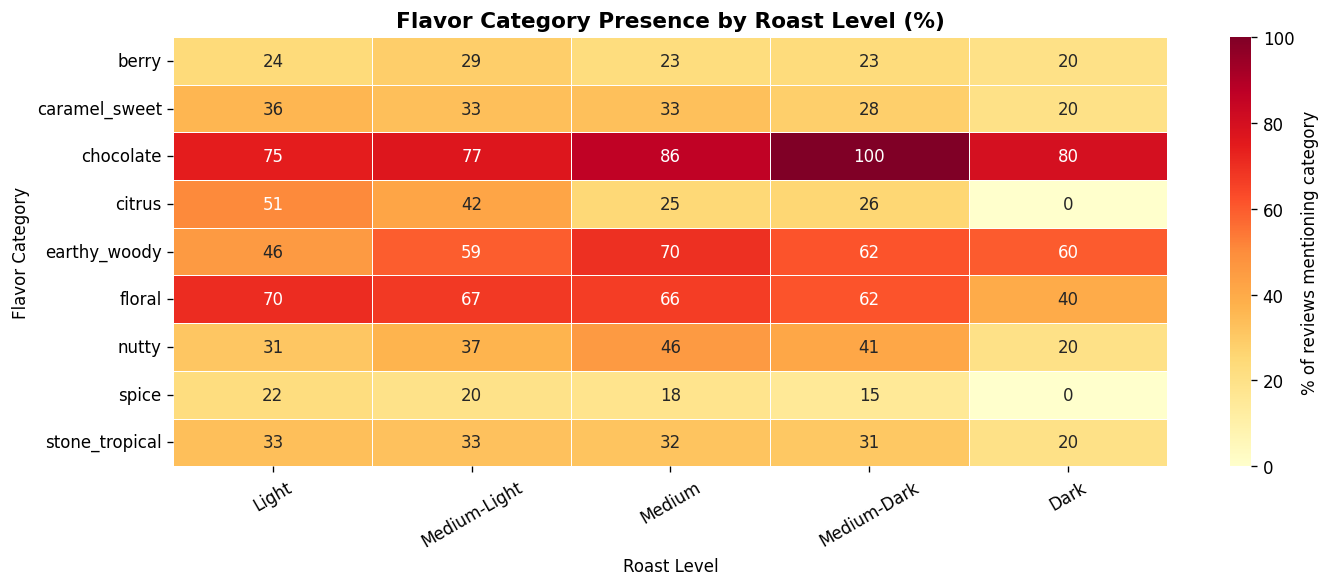

In [13]:
# ── Flavor category presence by roast level ───────────────────────────────────
# Build a category-level binary matrix
all_cats = sorted(set(FLAVOR_TERMS.values()))

def flavor_categories(flavor_list):
    return list({FLAVOR_TERMS[f] for f in flavor_list})

df['flavor_cats'] = df['flavors'].apply(flavor_categories)

cat_matrix = pd.DataFrame(
    [{cat: int(cat in cats) for cat in all_cats} for cats in df['flavor_cats']],
    index=df.index
)
cat_matrix['roast'] = df['roast'].values

roast_flavor_pct = (
    cat_matrix.groupby('roast', observed=True)[all_cats]
    .mean()
    .reindex(roast_order)
    * 100
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    roast_flavor_pct.T, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% of reviews mentioning category'}, ax=ax
)
ax.set_title('Flavor Category Presence by Roast Level (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Roast Level'); ax.set_ylabel('Flavor Category')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Section 5: Flavor Co-occurrence — PMI Analysis

Raw co-occurrence counts are biased toward common flavors. **Pointwise Mutual Information (PMI)** normalizes by marginal frequency, revealing which pairs co-occur *more than chance* — these are the flavors that genuinely go well together.

$$\text{PMI}(x, y) = \log_2 \frac{P(x, y)}{P(x) \cdot P(y)}$$

In [14]:
# ── Build binary term matrix ──────────────────────────────────────────────────
# Use only flavor terms that appear in ≥20 reviews for stability
min_freq = 20
vocab = [term for term, cnt in all_flavor_counts.items() if cnt >= min_freq]
print(f'Stable vocabulary ({min_freq}+ reviews): {len(vocab)} terms')

term_matrix = pd.DataFrame(
    [{t: int(t in flavors) for t in vocab} for flavors in df['flavors']],
    index=df.index
)

N = len(term_matrix)
P_single = term_matrix.sum() / N  # marginal probability for each term

# Co-occurrence counts
co_counts = term_matrix.T.dot(term_matrix).astype(float)
np.fill_diagonal(co_counts.values, 0)

# PMI matrix
pmi_matrix = pd.DataFrame(index=vocab, columns=vocab, dtype=float)
for t1 in vocab:
    for t2 in vocab:
        if t1 == t2:
            pmi_matrix.loc[t1, t2] = 0.0
            continue
        p_joint = co_counts.loc[t1, t2] / N
        if p_joint == 0:
            pmi_matrix.loc[t1, t2] = -np.inf
        else:
            pmi_matrix.loc[t1, t2] = np.log2(p_joint / (P_single[t1] * P_single[t2]))

print('PMI matrix computed.')
pmi_matrix.head(3)

Stable vocabulary (20+ reviews): 70 terms
PMI matrix computed.


,grapefruit zest,black cherry,floral,chocolate,vanilla,dark chocolate,cherry,grapefruit,honeysuckle,apricot,...,walnut,earth,ginger,wisteria,toffee,brown sugar,pecan,nutty,blueberry,cocoa nib
grapefruit zest,0.000000,-0.085036,0.074644,0.002888,0.806228,0.384251,-0.358192,3.647328,-0.350497,-0.106731,...,-0.017922,0.213404,-0.137504,0.697437,0.358454,-1.371559,-inf,-1.963474,-1.877744,0.169281
black cherry,-0.085036,0.000000,0.274312,0.452483,0.462274,0.760189,3.467779,-0.174673,0.764980,-inf,...,-inf,0.869449,-inf,0.768520,-1.307429,-0.715513,0.071083,0.277534,-inf,-2.303956
floral,0.074644,0.274312,0.000000,-0.110453,0.006098,-0.016355,0.092740,-0.014993,0.434335,0.201391,...,0.044444,-0.586727,-0.174673,0.822539,0.361926,-0.461196,-0.522597,-0.135573,-1.329952,0.093319


In [15]:
# ── Top flavor pairs by PMI ───────────────────────────────────────────────────
pairs = []
for i, t1 in enumerate(vocab):
    for t2 in vocab[i+1:]:
        pmi_val = pmi_matrix.loc[t1, t2]
        co_cnt  = int(co_counts.loc[t1, t2])
        if np.isfinite(pmi_val) and co_cnt >= 10:
            pairs.append({'flavor_1': t1, 'flavor_2': t2,
                          'pmi': pmi_val, 'co_count': co_cnt})

pairs_df = pd.DataFrame(pairs).sort_values('pmi', ascending=False)

print('=== Top 20 Flavor Pairs by PMI (most "surprising" co-occurrences) ===')
pairs_df.head(20).reset_index(drop=True).style.format({'pmi': '{:.2f}', 'co_count': '{:,}'})

=== Top 20 Flavor Pairs by PMI (most "surprising" co-occurrences) ===


,flavor_1,flavor_2,pmi,co_count
0,pipe tobacco,tobacco,4.96,61
1,cinnamon,nutmeg,4.40,10
2,orange zest,orange,3.70,121
3,grapefruit zest,grapefruit,3.65,156
4,guava,strawberry,3.58,20
5,black cherry,cherry,3.47,99
6,pipe tobacco,earth,3.38,14
7,tobacco,earth,3.24,14
8,roasted cacao,frankincense,2.83,10
9,lemon,lemon zest,2.81,76


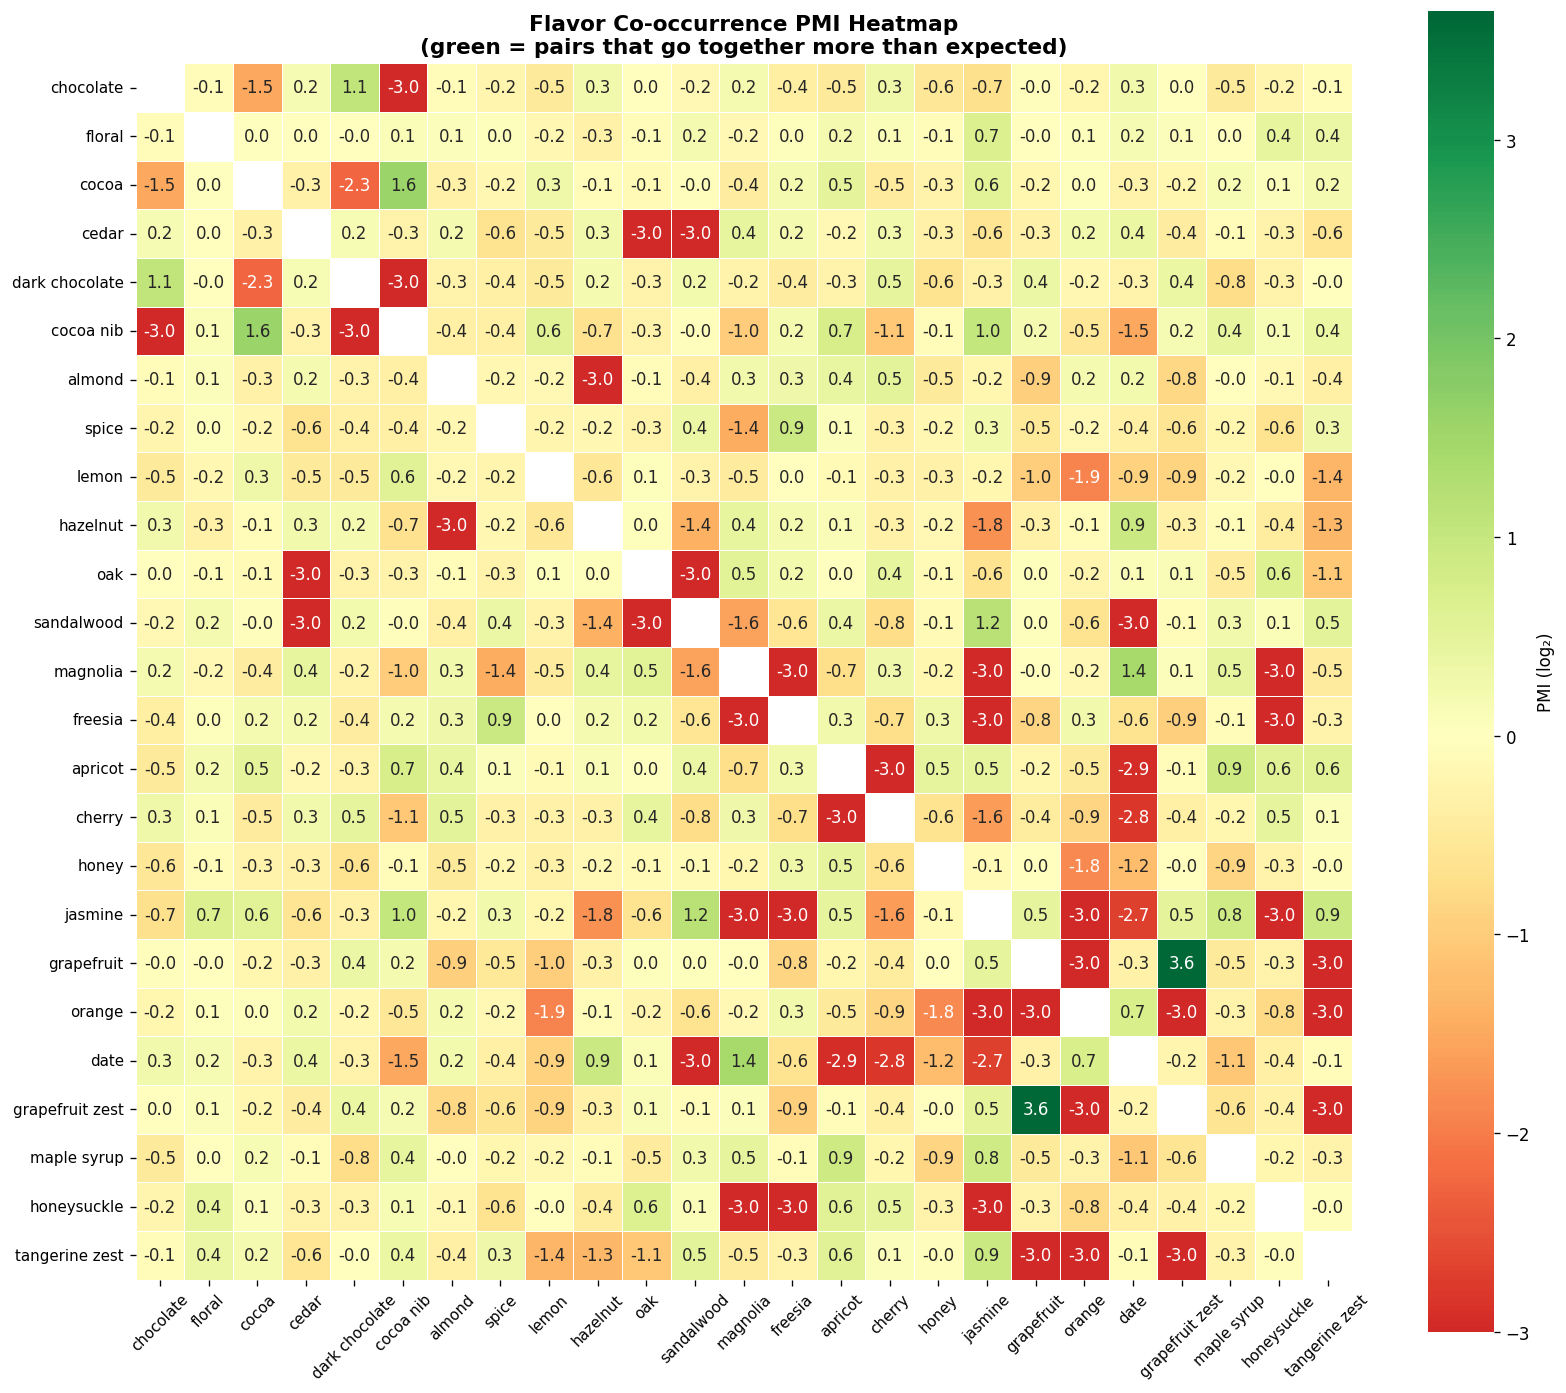

In [16]:
# ── PMI heatmap for top 25 terms ─────────────────────────────────────────────
top25 = freq_df['flavor'].head(25).tolist()
pmi_sub = pmi_matrix.loc[top25, top25].astype(float).clip(lower=-3, upper=6)
# Replace -inf with -3 for display
pmi_sub = pmi_sub.replace(-np.inf, -3)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.eye(len(top25), dtype=bool)  # mask diagonal
sns.heatmap(
    pmi_sub, annot=True, fmt='.1f', cmap='RdYlGn',
    center=0, linewidths=0.4, linecolor='white',
    mask=mask, square=True,
    cbar_kws={'label': 'PMI (log₂)'}, ax=ax
)
ax.set_title('Flavor Co-occurrence PMI Heatmap\n(green = pairs that go together more than expected)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

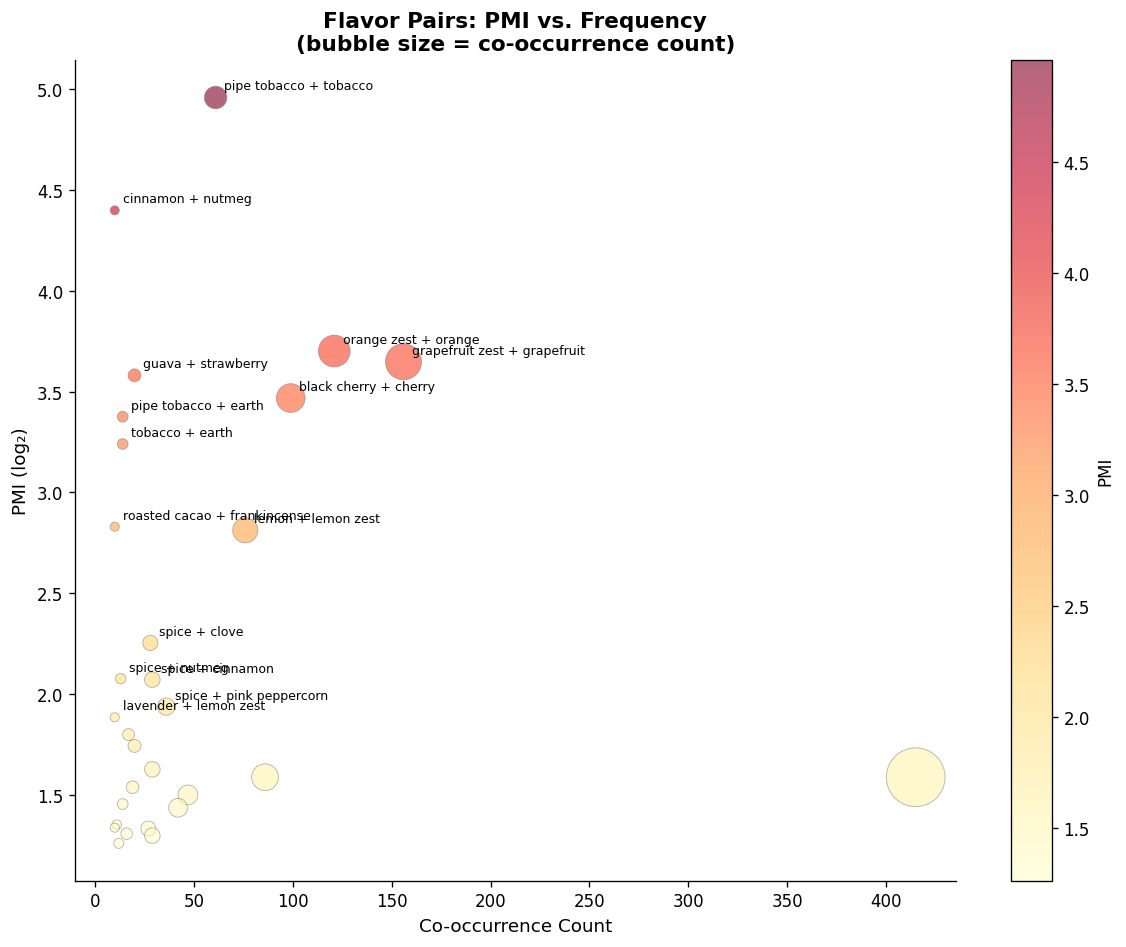

In [17]:
# ── Bubble chart: top pairs by PMI and co-count ───────────────────────────────
top_pairs = pairs_df.head(30).copy()
top_pairs['label'] = top_pairs['flavor_1'] + ' + ' + top_pairs['flavor_2']

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    top_pairs['co_count'], top_pairs['pmi'],
    s=top_pairs['co_count'] * 3, alpha=0.6,
    c=top_pairs['pmi'], cmap='YlOrRd', edgecolors='gray', linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='PMI')

for _, row in top_pairs.head(15).iterrows():
    ax.annotate(row['label'], (row['co_count'], row['pmi']),
                fontsize=7.5, ha='left', va='bottom',
                xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Co-occurrence Count', fontsize=11)
ax.set_ylabel('PMI (log₂)', fontsize=11)
ax.set_title('Flavor Pairs: PMI vs. Frequency\n(bubble size = co-occurrence count)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6: Flavor Network & Community Detection

We build a graph where:
- **Nodes** = flavor terms
- **Edges** = pair has PMI > threshold (meaningful co-occurrence)
- **Communities** = detected with greedy modularity — clusters of flavors that frequently appear together

In [18]:
# ── Build network ─────────────────────────────────────────────────────────────
PMI_THRESHOLD = 0.5   # only edges with meaningful positive association
CO_COUNT_MIN  = 10    # require at least 10 co-occurrences

G = nx.Graph()
for _, row in pairs_df.iterrows():
    if row['pmi'] >= PMI_THRESHOLD and row['co_count'] >= CO_COUNT_MIN:
        G.add_edge(row['flavor_1'], row['flavor_2'],
                   weight=row['pmi'], count=row['co_count'])

print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')

# Community detection
communities = list(greedy_modularity_communities(G, weight='weight'))
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

print(f'Communities detected: {len(communities)}')
for i, comm in enumerate(communities):
    print(f'  Community {i}: {sorted(comm)}')

Nodes: 63, Edges: 132
Communities detected: 8
  Community 0: ['blueberry', 'brown sugar', 'caramel', 'chocolate', 'cocoa powder', 'dark chocolate', 'date', 'gardenia', 'hazelnut', 'magnolia', 'molasses', 'nutty', 'oak', 'orange', 'orange zest']
  Community 1: ['almond', 'apricot', 'black cherry', 'cherry', 'honeysuckle', 'maple syrup', 'nougat', 'peach', 'plum', 'red currant']
  Community 2: ['bergamot', 'floral', 'jasmine', 'mango', 'rose', 'sandalwood', 'tangerine zest', 'toffee', 'wisteria']
  Community 3: ['blackberry', 'cocoa', 'cocoa nib', 'ginger', 'guava', 'hibiscus', 'myrrh', 'strawberry', 'violet']
  Community 4: ['cinnamon', 'clove', 'mulberry', 'nutmeg', 'pink peppercorn', 'spice']
  Community 5: ['freesia', 'grapefruit', 'grapefruit zest', 'honey', 'lilac', 'raspberry']
  Community 6: ['frankincense', 'lavender', 'lemon', 'lemon zest', 'roasted cacao']
  Community 7: ['earth', 'pipe tobacco', 'tobacco']


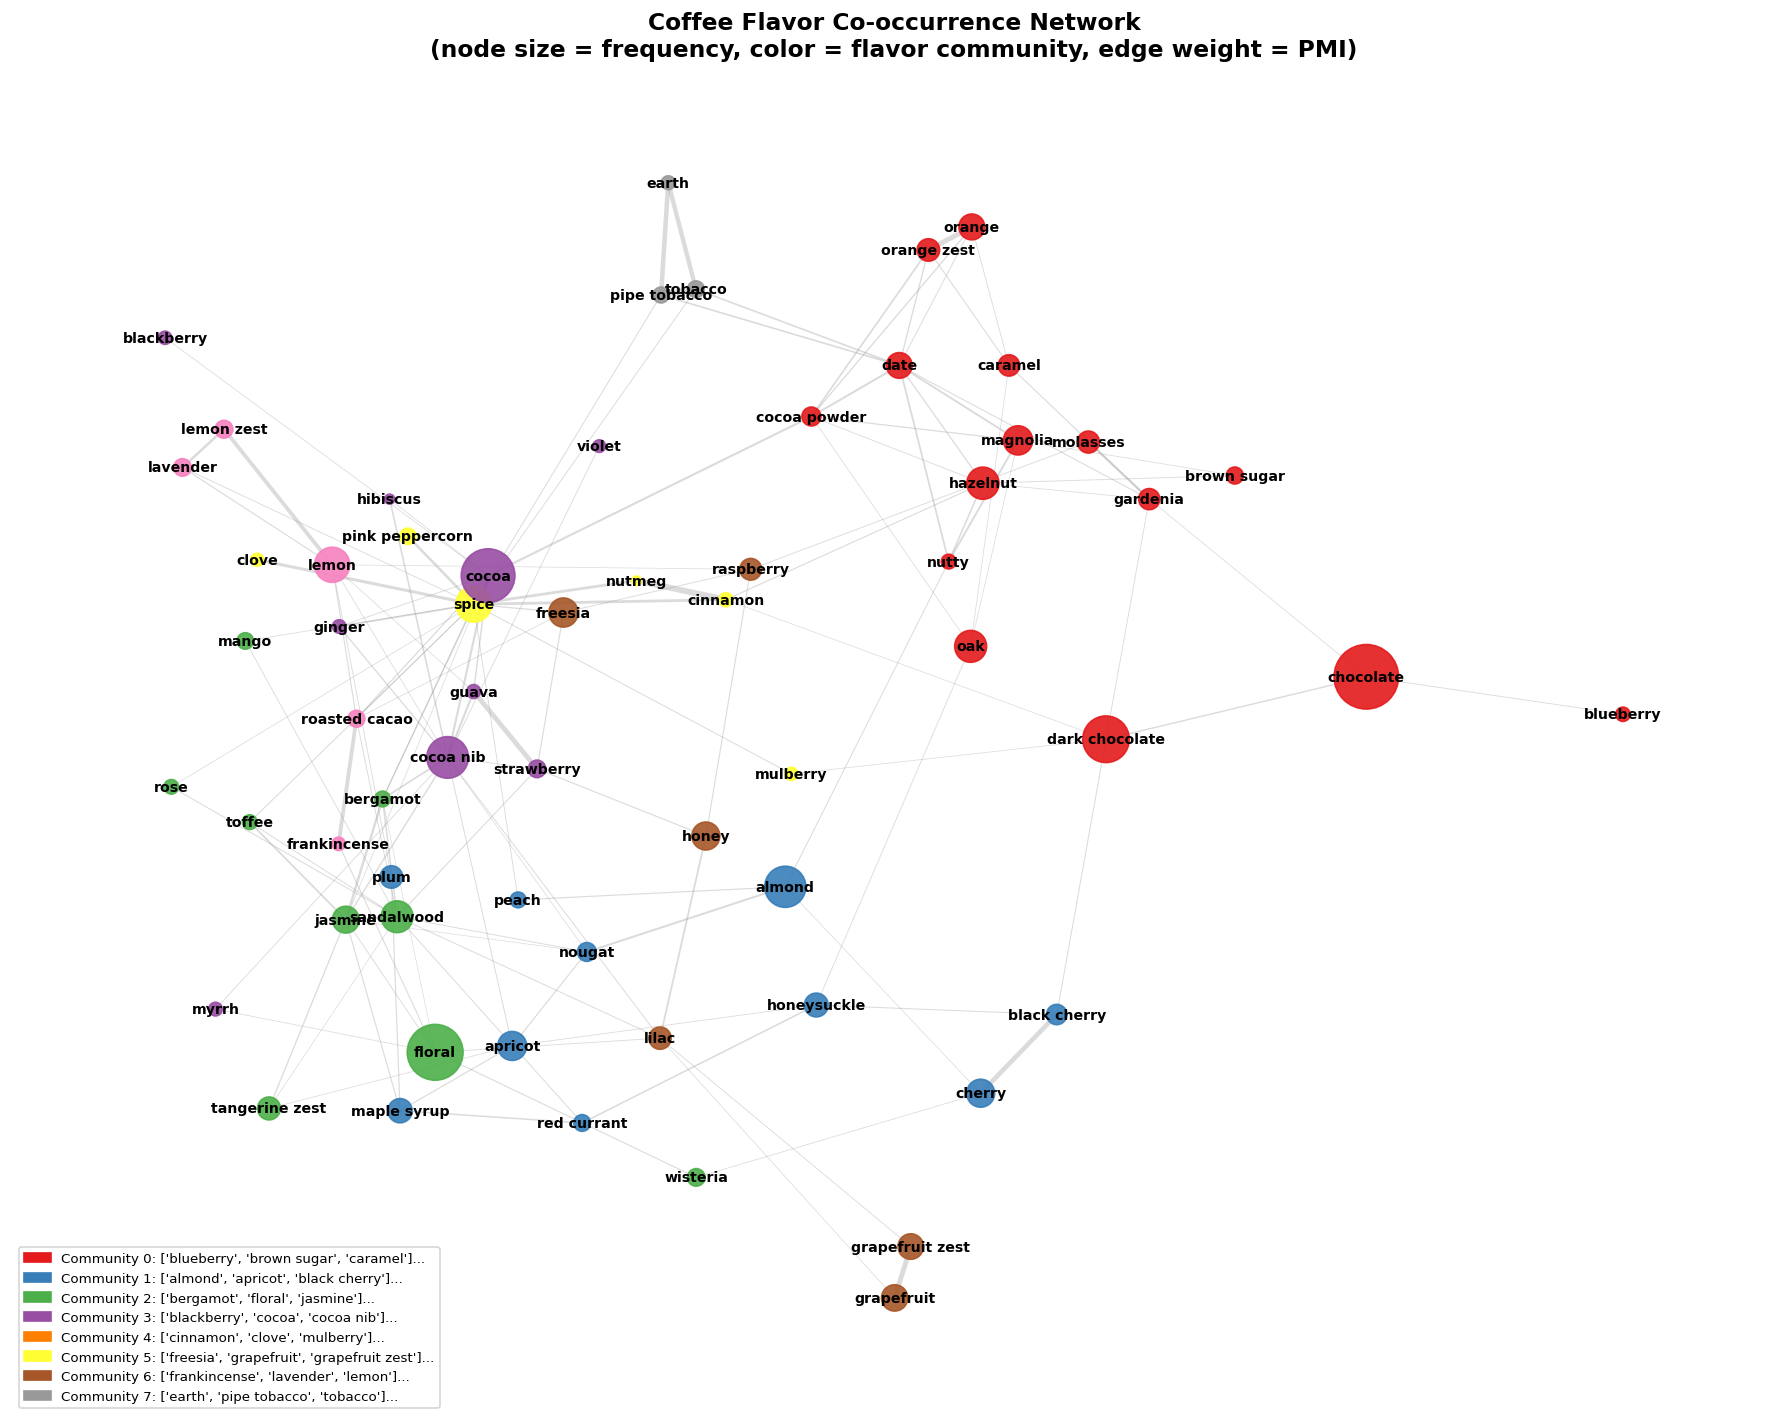

In [19]:
# ── Network visualization ─────────────────────────────────────────────────────
# Node size = frequency, color = community
node_freq   = {t: all_flavor_counts.get(t, 1) for t in G.nodes()}
node_sizes  = [node_freq[n] * 1.5 for n in G.nodes()]
node_colors = [community_map.get(n, 0) for n in G.nodes()]

edges       = G.edges(data=True)
edge_weights = [d['weight'] for (_, _, d) in G.edges(data=True)]
edge_widths  = [w / max(edge_weights) * 4 for w in edge_weights]

pos = nx.spring_layout(G, k=0.8, iterations=150, seed=SEED)

fig, ax = plt.subplots(figsize=(15, 12))
nx.draw_networkx_edges(
    G, pos, width=edge_widths, alpha=0.35,
    edge_color='#999999', ax=ax
)
nc = nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes,
    node_color=node_colors, cmap=plt.cm.Set1,
    alpha=0.9, ax=ax
)
nx.draw_networkx_labels(
    G, pos, font_size=8.5, font_weight='bold', ax=ax
)

ax.set_title(
    'Coffee Flavor Co-occurrence Network\n'
    '(node size = frequency, color = flavor community, edge weight = PMI)',
    fontsize=14, fontweight='bold'
)
ax.axis('off')

# Community legend
comm_colors = plt.cm.Set1(np.linspace(0, 0.9, len(communities)))
patches = [
    mpatches.Patch(color=comm_colors[i], label=f'Community {i}: {sorted(communities[i])[:3]}...')
    for i in range(len(communities))
]
ax.legend(handles=patches, loc='lower left', fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.show()

## Section 7: What Predicts High Ratings?

We train a **Random Forest classifier** to distinguish top-quartile coffees from the rest. Feature importances then reveal which flavor terms, origins, and roast levels are most predictive of quality.

In [20]:
# ── Feature matrix ────────────────────────────────────────────────────────────
# Binary flavor features
flavor_feats = term_matrix.copy()
flavor_feats.index = df.index

# Roast level (ordinal encode)
roast_enc = df['roast'].cat.codes  # Light=0 ... Dark=4
flavor_feats['roast_level'] = roast_enc.values

# Top origins as binary dummies (origins with ≥30 reviews)
top_origin_list = df['origin_1'].value_counts()[lambda x: x >= 30].index
for orig in top_origin_list:
    flavor_feats[f'origin_{orig}'] = (df['origin_1'] == orig).astype(int).values

# Drop rows with any NaN in target
valid_mask = df['high_rated'].notna()
X = flavor_feats[valid_mask].fillna(0).astype(float)
y = df[valid_mask]['high_rated']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'High-rated share (train): {y_train.mean():.1%}')

Train: (1664, 80), Test: (416, 80)
High-rated share (train): 41.3%


In [21]:
# ── Train Random Forest ───────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Standard', 'High-Rated']))

              precision    recall  f1-score   support

    Standard       0.79      0.82      0.81       244
  High-Rated       0.73      0.69      0.71       172

    accuracy                           0.77       416
   macro avg       0.76      0.76      0.76       416
weighted avg       0.77      0.77      0.77       416



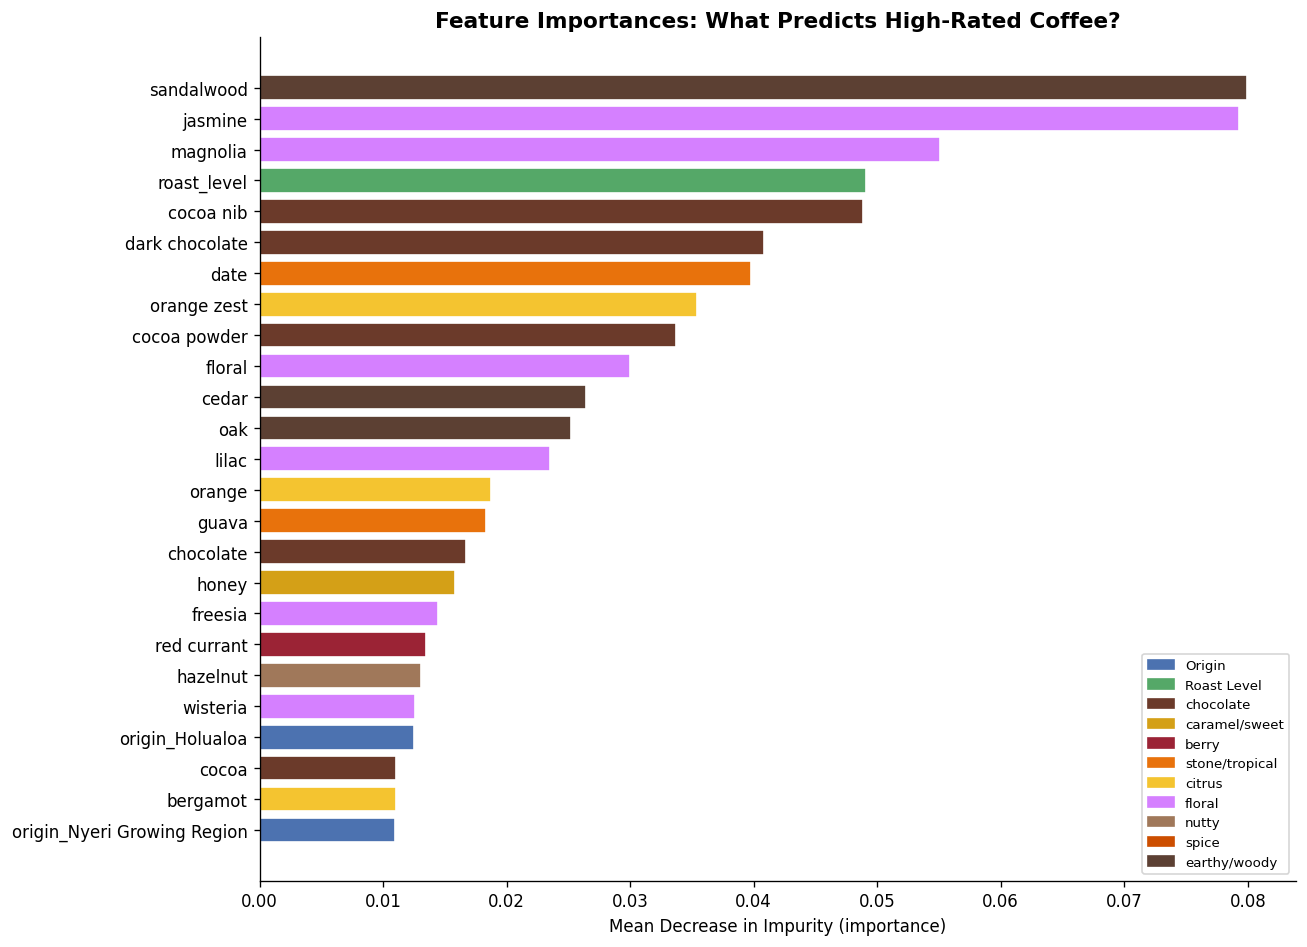

In [22]:
# ── Feature importances ───────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(25)

# Color by feature type
def feature_color(name):
    if name.startswith('origin_'):   return '#4C72B0'
    if name == 'roast_level':        return '#55A868'
    cat = FLAVOR_TERMS.get(name)
    return cat_palette.get(cat, '#999999')

feat_colors = [feature_color(n) for n in top_features.index]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top_features.index, top_features.values,
               color=feat_colors, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Feature Importances: What Predicts High-Rated Coffee?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity (importance)')

# Legend
type_patches = [
    mpatches.Patch(color='#4C72B0', label='Origin'),
    mpatches.Patch(color='#55A868', label='Roast Level'),
] + [mpatches.Patch(color=v, label=k.replace('_', '/')) for k, v in cat_palette.items()]
ax.legend(handles=type_patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

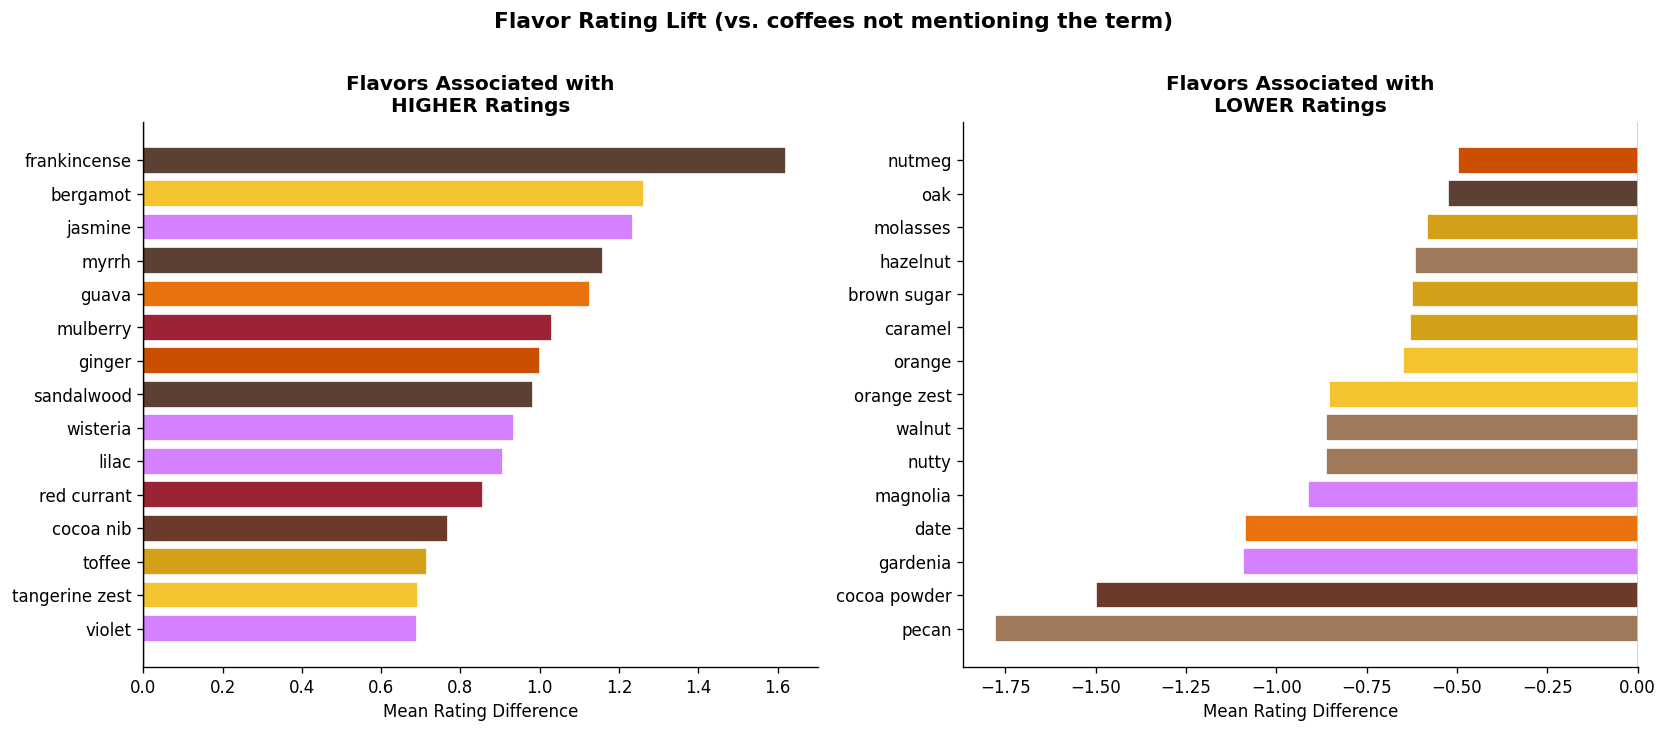

In [23]:
# ── Mean rating: high-rated vs standard coffees, by flavor term ───────────────
# What is the difference in mean rating between coffees that mention a flavor vs. those that don't?
rating_lift = {}
for term in vocab:
    with_term    = df[term_matrix[term] == 1]['rating']
    without_term = df[term_matrix[term] == 0]['rating']
    if len(with_term) >= 15:
        rating_lift[term] = with_term.mean() - without_term.mean()

lift_df = pd.Series(rating_lift).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top positive lift terms (associated with higher ratings)
top_pos = lift_df.head(15)
axes[0].barh(top_pos.index, top_pos.values,
             color=[cat_palette.get(FLAVOR_TERMS.get(t), '#888') for t in top_pos.index],
             edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Flavors Associated with\nHIGHER Ratings', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Rating Difference')
axes[0].axvline(0, color='black', linewidth=0.8)

# Top negative lift terms (associated with lower ratings)
top_neg = lift_df.tail(15)
axes[1].barh(top_neg.index, top_neg.values,
             color=[cat_palette.get(FLAVOR_TERMS.get(t), '#888') for t in top_neg.index],
             edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Flavors Associated with\nLOWER Ratings', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Rating Difference')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Flavor Rating Lift (vs. coffees not mentioning the term)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Section 8: Cluster Analysis — Flavor Profiles

K-Means on the full flavor term matrix (not on PCA) groups coffees into distinct sensory profiles. We then characterize each cluster and compare ratings.

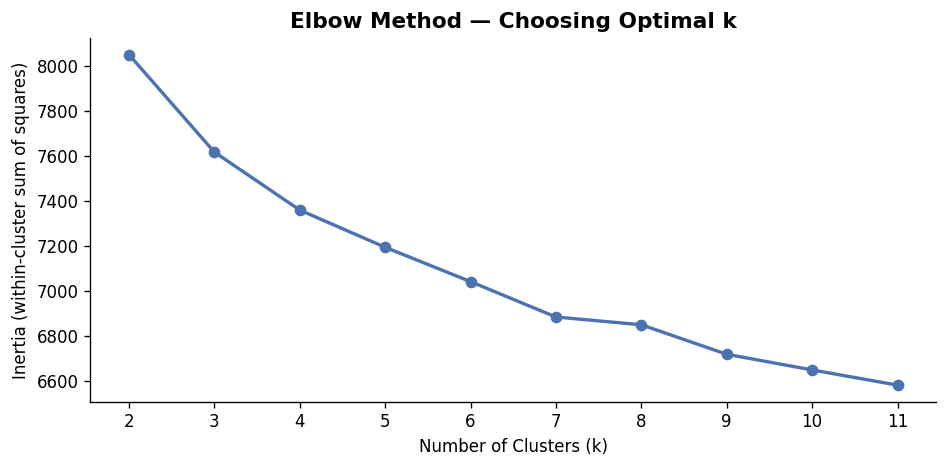

In [24]:
# ── Elbow method to choose k ──────────────────────────────────────────────────
X_flavor = term_matrix.fillna(0).astype(float)
inertias = []
k_range  = range(2, 12)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_flavor)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, 'o-', color='#4C72B0', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Method — Choosing Optimal k', fontsize=13, fontweight='bold')
ax.set_xticks(k_range)
plt.tight_layout()
plt.show()

In [25]:
# ── Fit K-Means with chosen k ─────────────────────────────────────────────────
K = 5  # adjust based on elbow plot
km_final = KMeans(n_clusters=K, random_state=SEED, n_init=20)
df['cluster'] = km_final.fit_predict(X_flavor)

print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    508
1    414
2    520
3    228
4    410
Name: count, dtype: int64


In [26]:
# ── Cluster characterization: top flavors per cluster ────────────────────────
cluster_profiles = {}
for c in range(K):
    mask = df['cluster'] == c
    sub  = X_flavor[mask]
    top  = sub.mean().sort_values(ascending=False).head(8)
    cluster_profiles[c] = top
    print(f'\nCluster {c} (n={mask.sum()}, mean rating={df[mask]["rating"].mean():.1f}):')
    print('  Top flavors:', ', '.join(top.index.tolist()))


Cluster 0 (n=508, mean rating=93.0):
  Top flavors: floral, cedar, almond, spice, lemon, honey, oak, sandalwood

Cluster 1 (n=414, mean rating=93.7):
  Top flavors: cocoa nib, cocoa, floral, cedar, lemon, jasmine, apricot, almond

Cluster 2 (n=520, mean rating=93.3):
  Top flavors: chocolate, dark chocolate, floral, cedar, almond, hazelnut, sandalwood, cherry

Cluster 3 (n=228, mean rating=92.5):
  Top flavors: cocoa, cocoa powder, floral, chocolate, cedar, roasted cacao, spice, lemon

Cluster 4 (n=410, mean rating=92.6):
  Top flavors: chocolate, cedar, floral, almond, magnolia, hazelnut, spice, oak


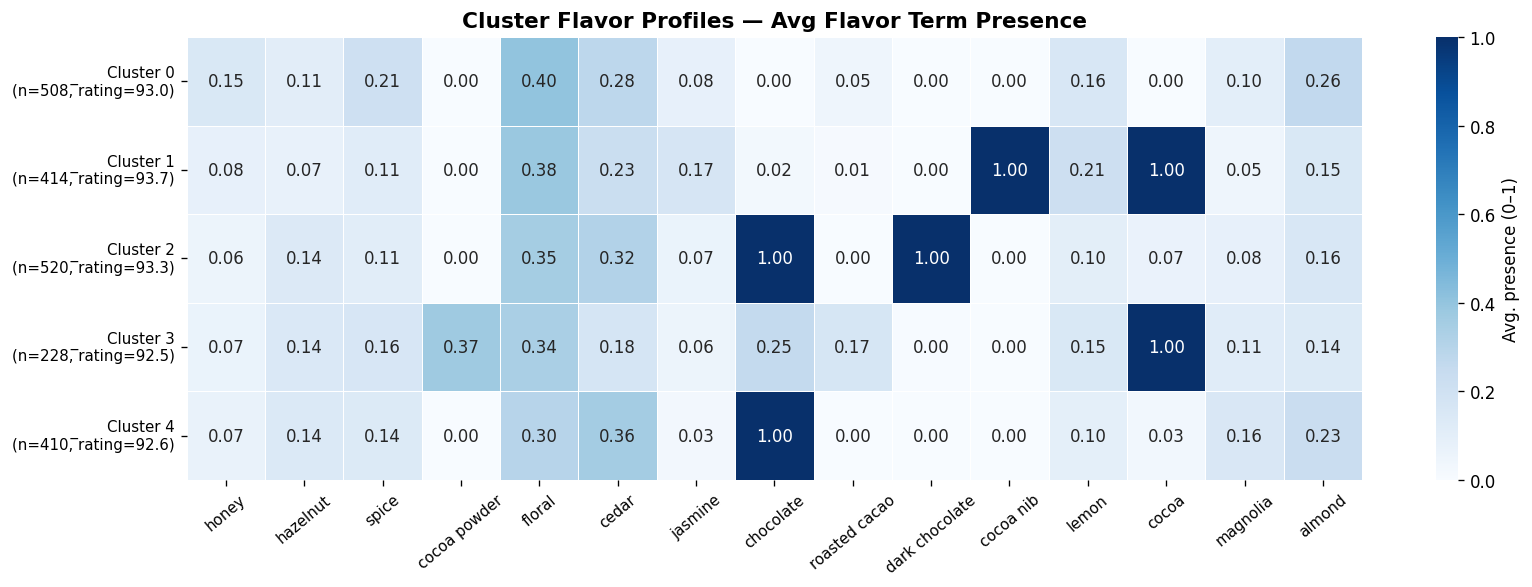

In [27]:
# ── Cluster heatmap ───────────────────────────────────────────────────────────
# Show top 5 terms per cluster as a heatmap
cluster_top_terms = set()
for c, profile in cluster_profiles.items():
    cluster_top_terms.update(profile.index[:6])
cluster_top_terms = list(cluster_top_terms)

cluster_heatmap = pd.DataFrame(index=range(K), columns=cluster_top_terms, dtype=float)
for c in range(K):
    mask = df['cluster'] == c
    cluster_heatmap.loc[c] = X_flavor[mask][cluster_top_terms].mean()

cluster_labels = [
    f'Cluster {c}\n(n={int((df["cluster"]==c).sum())}, \u0305rating={df[df["cluster"]==c]["rating"].mean():.1f})'
    for c in range(K)
]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    cluster_heatmap.astype(float), annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.4, linecolor='white',
    yticklabels=cluster_labels,
    cbar_kws={'label': 'Avg. presence (0–1)'}, ax=ax
)
ax.set_title('Cluster Flavor Profiles — Avg Flavor Term Presence', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

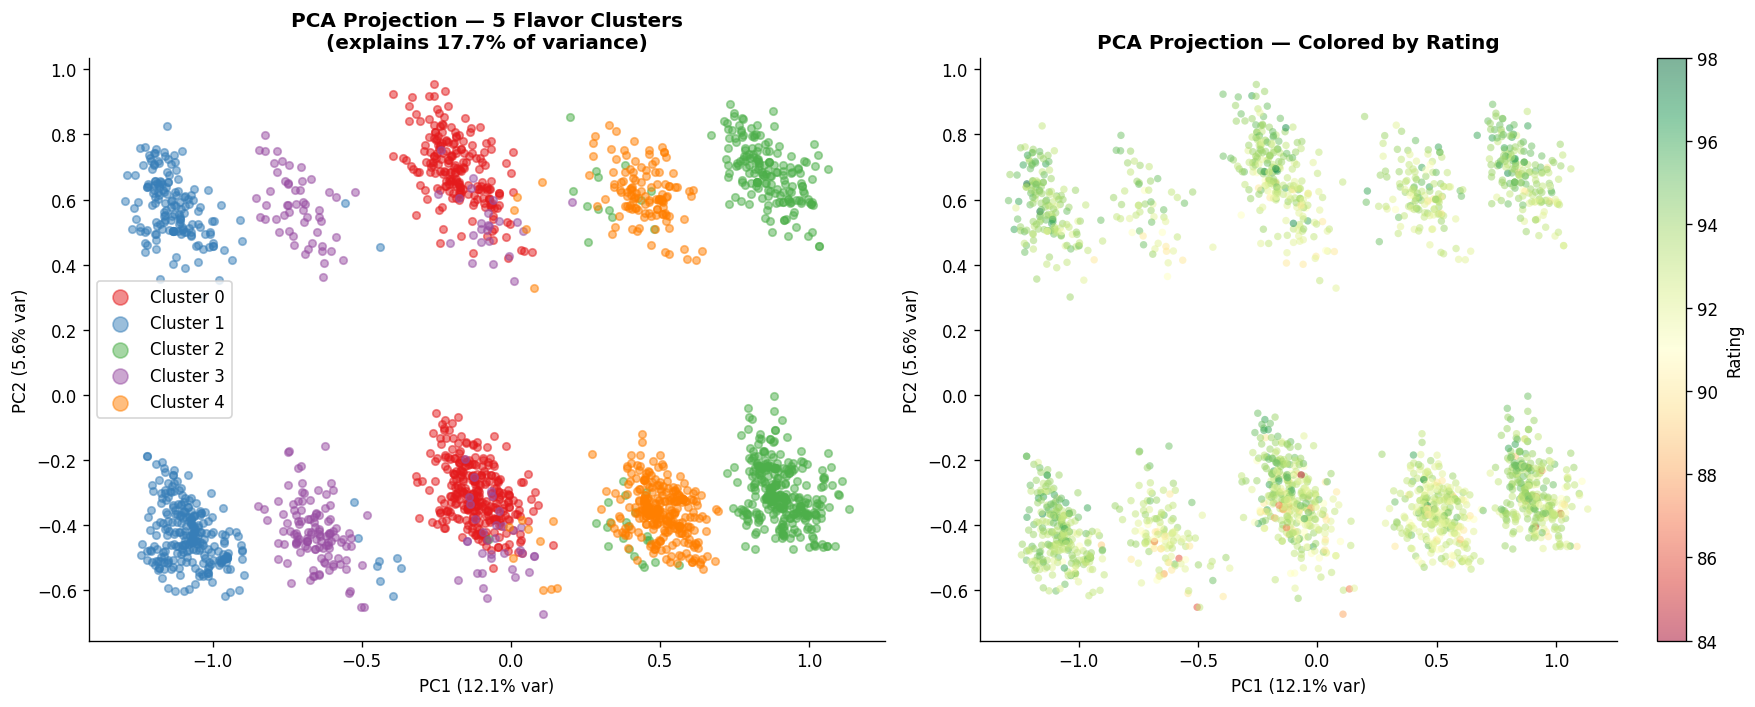

In [28]:
# ── PCA visualization of clusters ─────────────────────────────────────────────
pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(X_flavor)
pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'], index=df.index)
pca_df['cluster'] = df['cluster']
pca_df['rating']  = df['rating']
pca_df['roast']   = df['roast'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# By cluster
cluster_palette = sns.color_palette('Set1', K)
for c in range(K):
    sub = pca_df[pca_df['cluster'] == c]
    axes[0].scatter(sub['PC1'], sub['PC2'], s=20, alpha=0.5,
                    color=cluster_palette[c], label=f'Cluster {c}')
axes[0].set_title(f'PCA Projection — {K} Flavor Clusters\n'
                  f'(explains {pca.explained_variance_ratio_.sum():.1%} of variance)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].legend(markerscale=2)

# By rating
sc = axes[1].scatter(
    pca_df['PC1'], pca_df['PC2'],
    s=20, alpha=0.5, c=pca_df['rating'], cmap='RdYlGn', edgecolors='none'
)
plt.colorbar(sc, ax=axes[1], label='Rating')
axes[1].set_title('PCA Projection — Colored by Rating',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

plt.tight_layout()
plt.show()

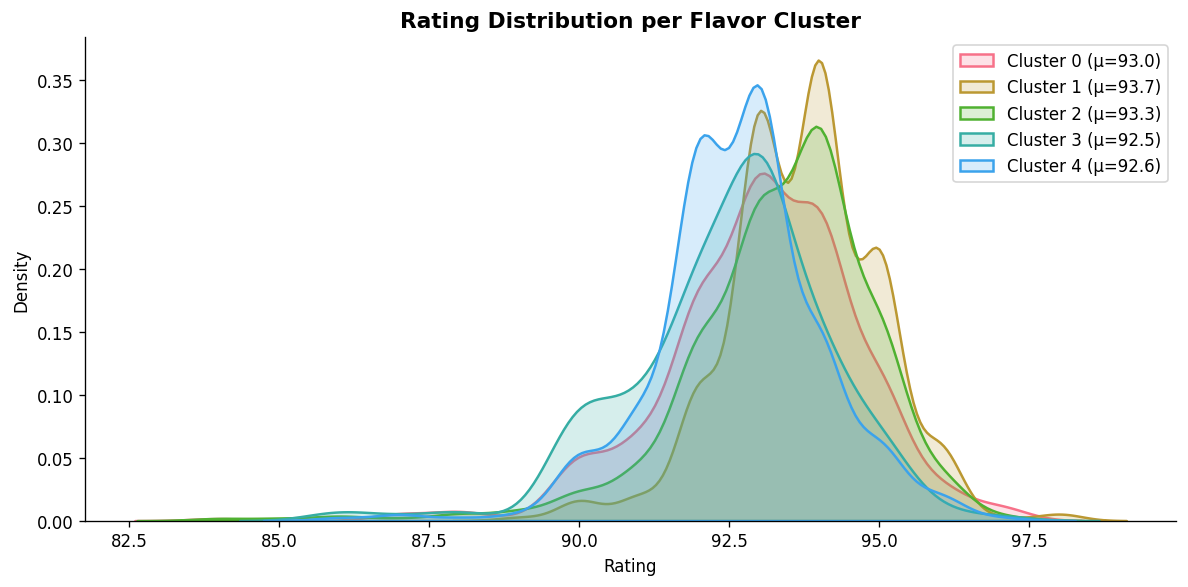

In [29]:
# ── Cluster rating distributions ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for c in range(K):
    data = df[df['cluster'] == c]['rating']
    sns.kdeplot(data, ax=ax, label=f'Cluster {c} (μ={data.mean():.1f})',
                fill=True, alpha=0.2, linewidth=1.5)

ax.set_title('Rating Distribution per Flavor Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## Section 9: Key Findings

---

### What flavors go well together?

The PMI analysis reveals flavor pairings that are meaningfully associated — not just common. Key clusters from the network:

- **Floral + Citrus** (jasmine, lemon blossom, tangerine): classic Ethiopia washed profile — these terms cluster tightly with high PMI
- **Chocolate + Nut** (dark chocolate, hazelnut, almond, caramel): the "classic cafe" profile — comforting, lower acidity
- **Berry + Stone fruit + Floral** (raspberry, peach, magnolia): natural-process fruity coffees, often light roast
- **Spice + Wood** (cedar, cinnamon, pipe tobacco, frankincense): earthy, savory coffees — often Central American origins

### What makes coffee highly rated?

From the feature importance and rating lift analyses:

1. **Origin matters most**: Hawaii (Kona), Panama (Gesha varieties), and Taiwan-roasted Ethiopian coffees consistently score highest
2. **Floral + citrus notes** are strongly associated with high ratings — jasmine, lemon blossom, bergamot
3. **Light-to-medium-light roast** correlates with higher ratings in this dataset (specialty market bias)
4. **Price is a weak predictor**: while expensive coffees (Gesha, Kona) do rate well, many moderately priced coffees score just as high — value exists
5. **Chocolate and nut notes** are common but not differentiating — their rating lift is near zero; they're baseline expectations
6. **Complexity matters**: high-rated coffees mention more distinct flavor terms on average

---

*Analysis by Adrian Rodriguez — Coffee Review Kaggle dataset*